In [ ]:
!pip install catboost lightgbm imbalanced-learn optuna shap -q
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 30.1 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv('/content/OR.csv')
df.columns = df.columns.str.strip()
df['License.Status'] = df['License.Status'].fillna(df['License.Status'].mode()[0])
df.reset_index(drop=True, inplace=True)
print("Shape:", df.shape)
print("Target distribution:\n", df['ACCIDENT.TYPE'].value_counts())

Shape: (13399, 14)
Target distribution:
 ACCIDENT.TYPE
Grievous Injured (Need Hospitalization)      6560
Fatal                                        6557
Minor Injury (No Need of Hospitalization)     282
Name: count, dtype: int64


In [ ]:
df['is_night'] = df['ACCIDENT.TIME'].apply(
    lambda x: 1 if 'Night' in str(x) or 'Late' in str(x) else 0)

df['is_weekend'] = (df['DAY.OF.OCCURANCE'] == 'Weekend').astype(int)

df['is_rural'] = (df['TYPE.OF.AREA'] == 'Rural').astype(int)

high_sev_collision = ['Head on Collision', 'Hit to Pedestrian', 'Fixed Object']
df['high_sev_collision'] = df['TYPE.OF.COLLISION'].isin(high_sev_collision).astype(int)

df['speed_zone'] = (df['SPEED.LIMIT'] == 'Yes').astype(int)

df['undivided'] = (df['CARRIAGEWAY.TYPES'] == 'UNDIVIDED CARRIAGEWAY').astype(int)

df['multilane'] = (df['NO.OF.LANE'] == 'More than Two').astype(int)

df['violation_flag'] = (df['Violation'] != 'No.violation').astype(int)

df['unlicensed'] = (df['License.Status'] == 'Involved_Unlicensed').astype(int)

df['night_rural'] = ((df['is_night'] == 1) & (df['is_rural'] == 1)).astype(int)

df['rural_speed'] = ((df['is_rural'] == 1) & (df['speed_zone'] == 1)).astype(int)

df['risky_driver'] = ((df['violation_flag'] == 1) & (df['unlicensed'] == 1)).astype(int)

print("After feature engineering — columns:", df.shape[1])

After feature engineering — columns: 26


In [ ]:
target_le = LabelEncoder()
df['target'] = target_le.fit_transform(df['ACCIDENT.TYPE'])
print("Class mapping:", dict(zip(target_le.classes_, target_le.transform(target_le.classes_))))

features = [c for c in df.columns if c not in ['ACCIDENT.TYPE', 'target']]
X_raw = df[features].copy()

le_dict = {}
for col in X_raw.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_raw[col] = le.fit_transform(X_raw[col].astype(str))
    le_dict[col] = le

X = X_raw.values
y = df['target'].values
feature_names = features
n_classes = len(np.unique(y))

Class mapping: {'Fatal': np.int64(0), 'Grievous Injured (Need Hospitalization)': np.int64(1), 'Minor Injury (No Need of Hospitalization)': np.int64(2)}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
unique, counts = np.unique(y_train_sm, return_counts=True)
print("After SMOTE:", dict(zip(target_le.classes_, counts)))

After SMOTE: {'Fatal': np.int64(5248), 'Grievous Injured (Need Hospitalization)': np.int64(5248), 'Minor Injury (No Need of Hospitalization)': np.int64(5248)}


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_score(model, X, y):
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    return scores.mean(), scores.std()

In [ ]:
lr = Pipeline([('scaler', StandardScaler()),
               ('clf', LogisticRegression(max_iter=2000, C=1.0,
                                          multi_class='multinomial',
                                          random_state=42))])
lr_cv_mean, lr_cv_std = cv_score(lr, X_train_sm, y_train_sm)
lr.fit(X_train_sm, y_train_sm)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(f"\nLogistic Regression | CV: {lr_cv_mean:.4f}±{lr_cv_std:.4f} | Test Acc: {lr_acc:.4f}")


Logistic Regression | CV: 0.5835±0.0057 | Test Acc: 0.4631


In [ ]:
def dt_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])}
    model = DecisionTreeClassifier(**params, random_state=42)
    return cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='accuracy', n_jobs=-1).mean()

dt_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
dt_study.optimize(dt_objective, n_trials=50, show_progress_bar=False)
dt_best = DecisionTreeClassifier(**dt_study.best_params, random_state=42)
dt_best.fit(X_train_sm, y_train_sm)
dt_acc = accuracy_score(y_test, dt_best.predict(X_test))
print(f"Decision Tree (Optuna) | Best CV: {dt_study.best_value:.4f} | Test Acc: {dt_acc:.4f}")

Decision Tree (Optuna) | Best CV: 0.6745 | Test Acc: 0.5347


In [ ]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])}
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    return cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='accuracy', n_jobs=-1).mean()

rf_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
rf_study.optimize(rf_objective, n_trials=50, show_progress_bar=False)
rf_best = RandomForestClassifier(**rf_study.best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train_sm, y_train_sm)
rf_acc = accuracy_score(y_test, rf_best.predict(X_test))
print(f"Random Forest (Optuna) | Best CV: {rf_study.best_value:.4f} | Test Acc: {rf_acc:.4f}")

Random Forest (Optuna) | Best CV: 0.7056 | Test Acc: 0.5713


In [ ]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5)}
    model = XGBClassifier(**params, objective='multi:softmax', num_class=n_classes,
                          eval_metric='mlogloss', random_state=42, n_jobs=-1)
    return cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='accuracy', n_jobs=-1).mean()

xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=60, show_progress_bar=False)
xgb_best = XGBClassifier(**xgb_study.best_params, objective='multi:softmax',
                          num_class=n_classes, eval_metric='mlogloss', random_state=42, n_jobs=-1)
xgb_best.fit(X_train_sm, y_train_sm)
xgb_acc = accuracy_score(y_test, xgb_best.predict(X_test))
print(f"XGBoost (Optuna) | Best CV: {xgb_study.best_value:.4f} | Test Acc: {xgb_acc:.4f}")

XGBoost (Optuna) | Best CV: 0.7136 | Test Acc: 0.5769


In [ ]:
def cat_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 800),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255)}
    model = CatBoostClassifier(**params, loss_function='MultiClass',
                                random_state=42, verbose=0)
    return cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='accuracy', n_jobs=-1).mean()

cat_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
cat_study.optimize(cat_objective, n_trials=50, show_progress_bar=False)
cat_best = CatBoostClassifier(**cat_study.best_params, loss_function='MultiClass',
                               random_state=42, verbose=0)
cat_best.fit(X_train_sm, y_train_sm)
cat_acc = accuracy_score(y_test, cat_best.predict(X_test))
print(f"CatBoost (Optuna) | Best CV: {cat_study.best_value:.4f} | Test Acc: {cat_acc:.4f}")

CatBoost (Optuna) | Best CV: 0.7087 | Test Acc: 0.5728


In [ ]:
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),}
    model = LGBMClassifier(**params, objective='multiclass', num_class=n_classes,
                            random_state=42, n_jobs=-1, verbose=-1)
    return cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='accuracy', n_jobs=-1).mean()

lgbm_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
lgbm_study.optimize(lgbm_objective, n_trials=60, show_progress_bar=False)
lgbm_best = LGBMClassifier(**lgbm_study.best_params, objective='multiclass',
                             num_class=n_classes, random_state=42, n_jobs=-1, verbose=-1)
lgbm_best.fit(X_train_sm, y_train_sm)
lgbm_acc = accuracy_score(y_test, lgbm_best.predict(X_test))
print(f"LightGBM (Optuna) | Best CV: {lgbm_study.best_value:.4f} | Test Acc: {lgbm_acc:.4f}")

LightGBM (Optuna) | Best CV: 0.7125 | Test Acc: 0.5847


In [ ]:
ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb_best),
        ('cat', cat_best),
        ('lgbm', lgbm_best),
        ('rf', rf_best)],
    voting='soft')
ensemble.fit(X_train_sm, y_train_sm)
ens_acc = accuracy_score(y_test, ensemble.predict(X_test))
print(f"\nSoft Voting Ensemble | Test Acc: {ens_acc:.4f}")


Soft Voting Ensemble | Test Acc: 0.5914


In [ ]:
results = {
    'Logistic Regression': (lr, lr_acc),
    'Decision Tree': (dt_best, dt_acc),
    'Random Forest': (rf_best, rf_acc),
    'XGBoost': (xgb_best, xgb_acc),
    'CatBoost': (cat_best, cat_acc),
    'LightGBM': (lgbm_best, lgbm_acc),
    'Ensemble': (ensemble, ens_acc),}
print("\n" + "="*65)
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC (OvR)':>15}")
print("="*65)
for name, (model, acc) in results.items():
    try:
        proba = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
    except:
        auc = float('nan')
    print(f"{name:<25} {acc:>10.4f} {auc:>15.4f}")
print("="*65)

best_name = max(results, key=lambda k: results[k][1])
best_model = results[best_name][0]
print(f"\nBest Model: {best_name}")
print(classification_report(y_test, best_model.predict(X_test),
                             target_names=target_le.classes_))


Model                       Accuracy   ROC-AUC (OvR)
Logistic Regression           0.4631          0.6221
Decision Tree                 0.5347          0.5930
Random Forest                 0.5713          0.6877
XGBoost                       0.5769          0.6906
CatBoost                      0.5728          0.6873
LightGBM                      0.5847          0.6992
Ensemble                      0.5914          0.7020

Best Model: Ensemble
                                           precision    recall  f1-score   support

                                    Fatal       0.62      0.60      0.61      1312
  Grievous Injured (Need Hospitalization)       0.60      0.60      0.60      1312
Minor Injury (No Need of Hospitalization)       0.10      0.14      0.12        56

                                 accuracy                           0.59      2680
                                macro avg       0.44      0.45      0.44      2680
                             weighted avg       0.60 

CONFUSION MATRIX

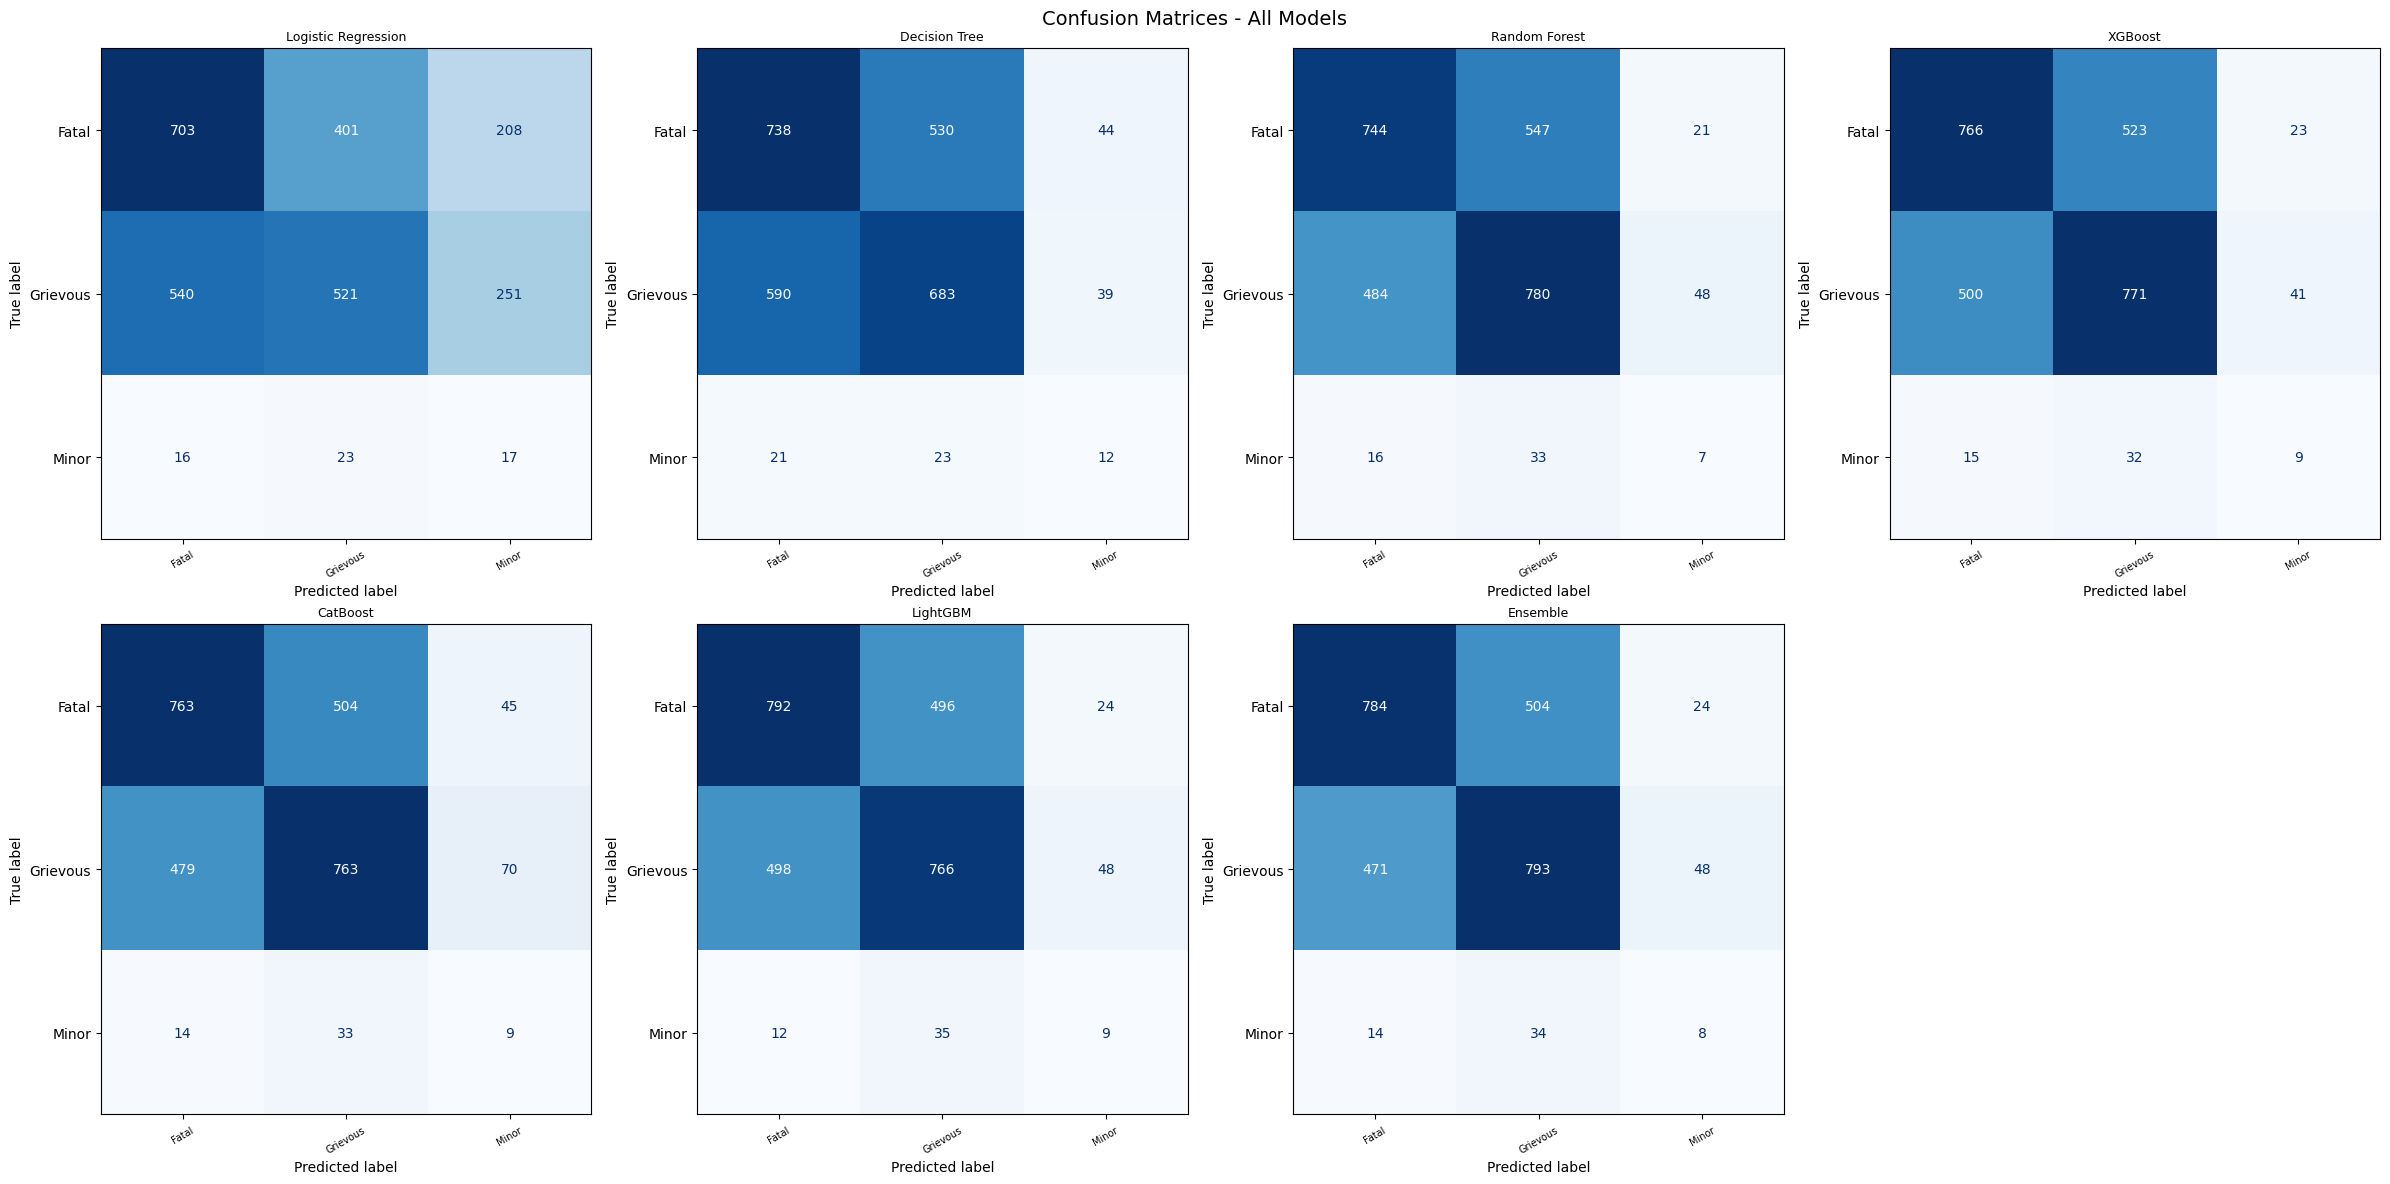

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()
for idx, (name, (model, _)) in enumerate(results.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fatal', 'Grievous', 'Minor'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=9)
    axes[idx].set_xticklabels(['Fatal', 'Grievous', 'Minor'], rotation=30, fontsize=7)
axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices - All Models', fontsize=14)
plt.tight_layout()
plt.savefig('/content/or_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

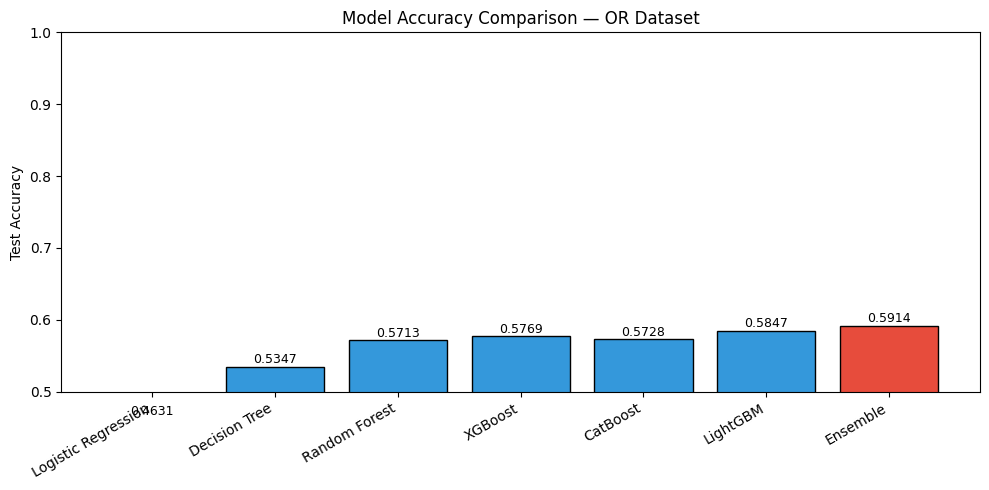

In [ ]:
plt.figure(figsize=(10, 5))
names = list(results.keys())
accs = [v[1] for v in results.values()]
colors = ['#e74c3c' if a == max(accs) else '#3498db' for a in accs]
bars = plt.bar(names, accs, color=colors, edgecolor='black')
plt.ylim(0.5, 1.0)
plt.ylabel('Test Accuracy')
plt.title('Model Accuracy Comparison — OR Dataset')
plt.xticks(rotation=30, ha='right')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/or_accuracy_comparison.png', dpi=150)
plt.show()


[SHAP] Random Forest ...


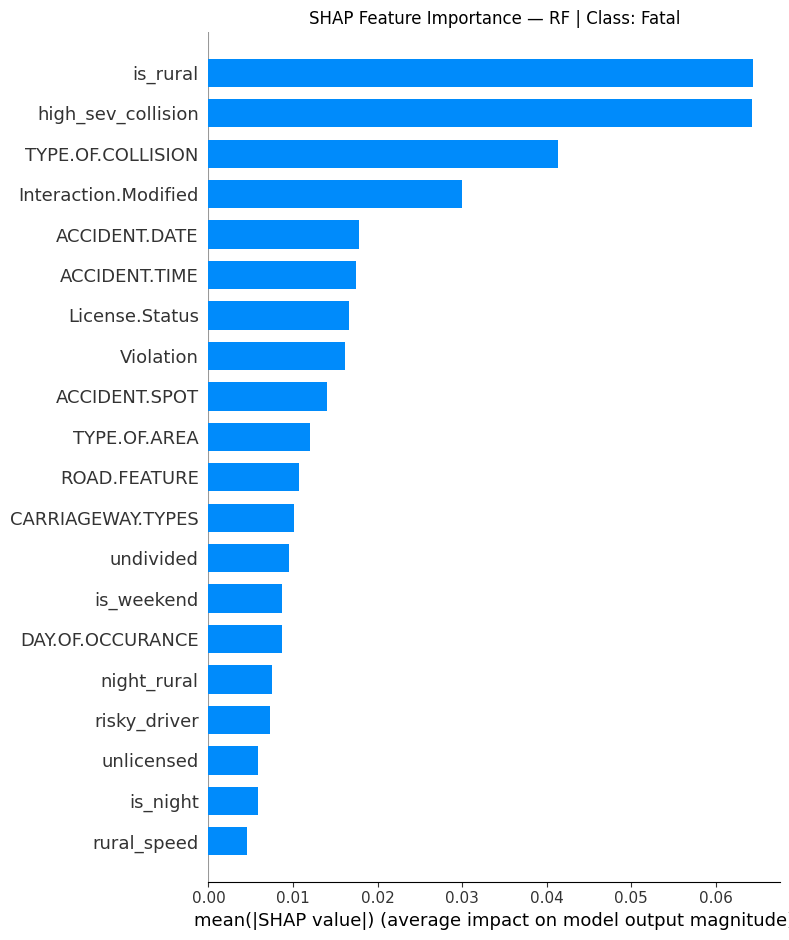

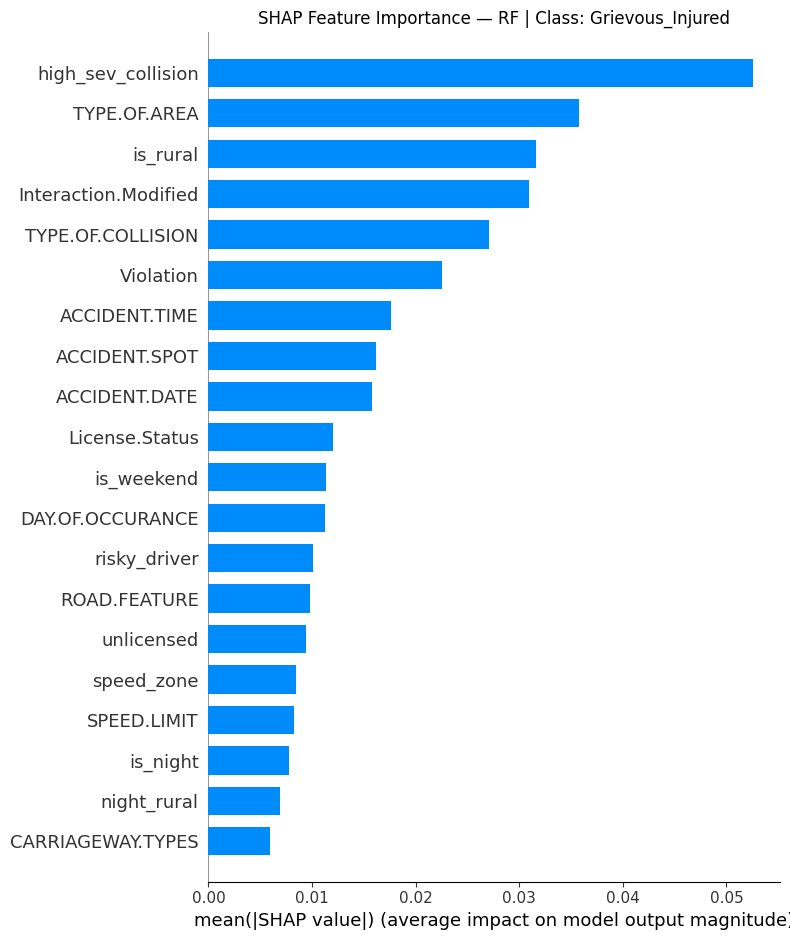

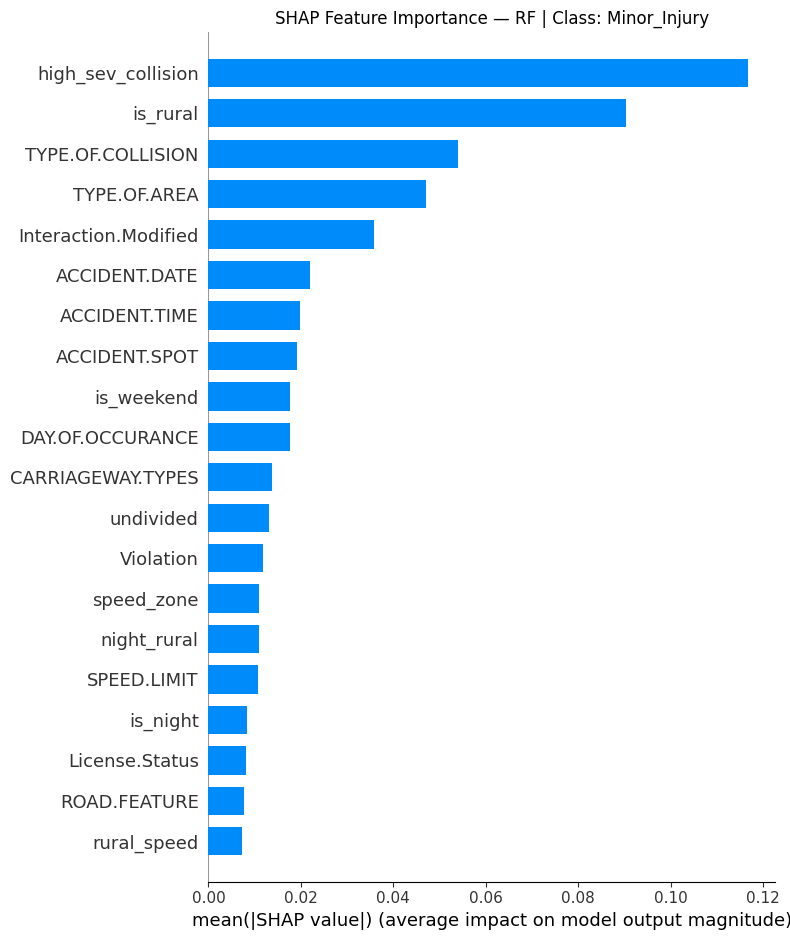


[RF] SHAP per class + average:
             Feature  RF_Fatal  RF_Grievous_Injured  RF_Minor_Injury  RF_Average
  high_sev_collision  0.064268             0.052548         0.116775    0.077864
            is_rural  0.064397             0.031665         0.090378    0.062147
   TYPE.OF.COLLISION  0.041410             0.027042         0.053993    0.040815
Interaction.Modified  0.030036             0.030965         0.035859    0.032286
        TYPE.OF.AREA  0.012013             0.035764         0.047092    0.031623
       ACCIDENT.DATE  0.017858             0.015757         0.022043    0.018553
       ACCIDENT.TIME  0.017403             0.017597         0.019895    0.018298
           Violation  0.016154             0.022581         0.011808    0.016847
       ACCIDENT.SPOT  0.013990             0.016197         0.019184    0.016457
          is_weekend  0.008729             0.011389         0.017608    0.012576
    DAY.OF.OCCURANCE  0.008722             0.011257         0.017576    0.012

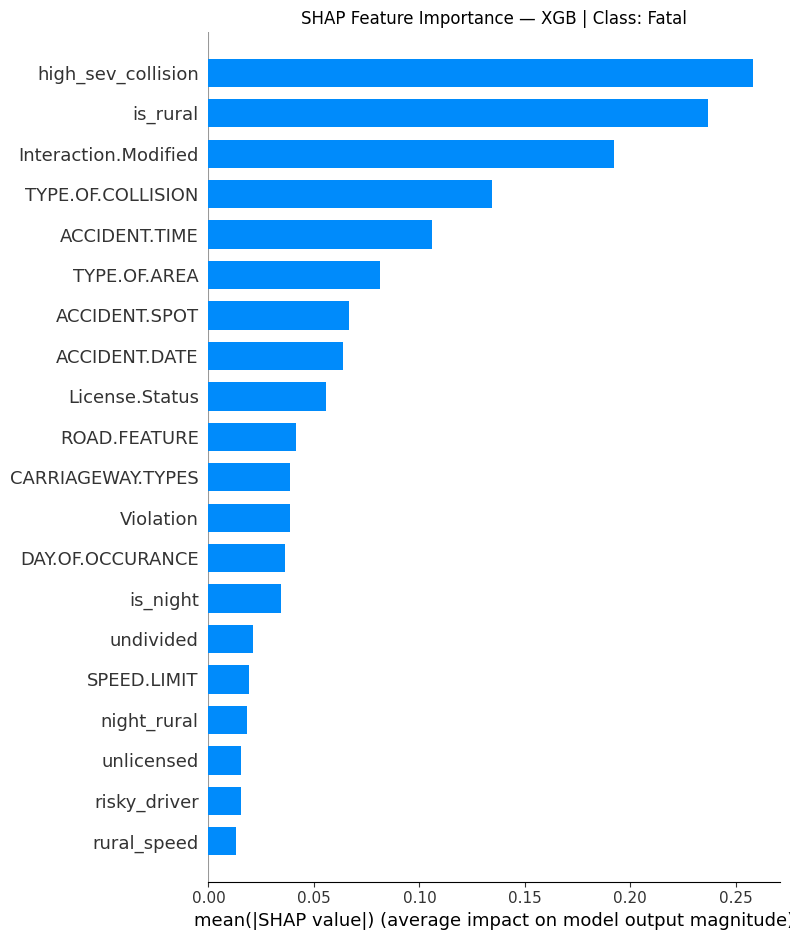

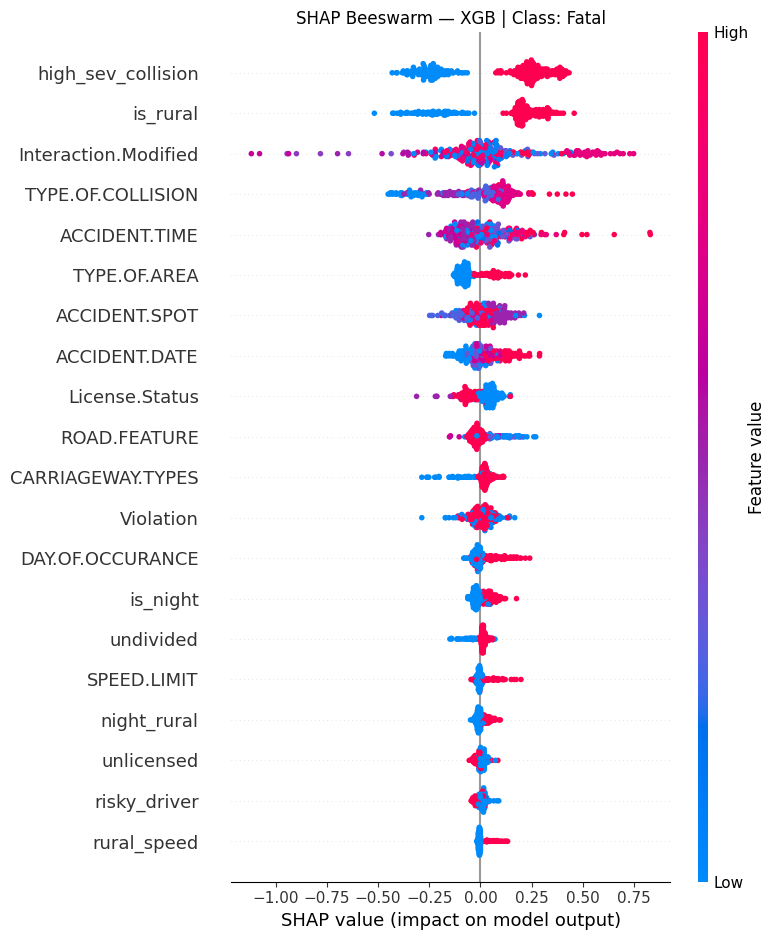

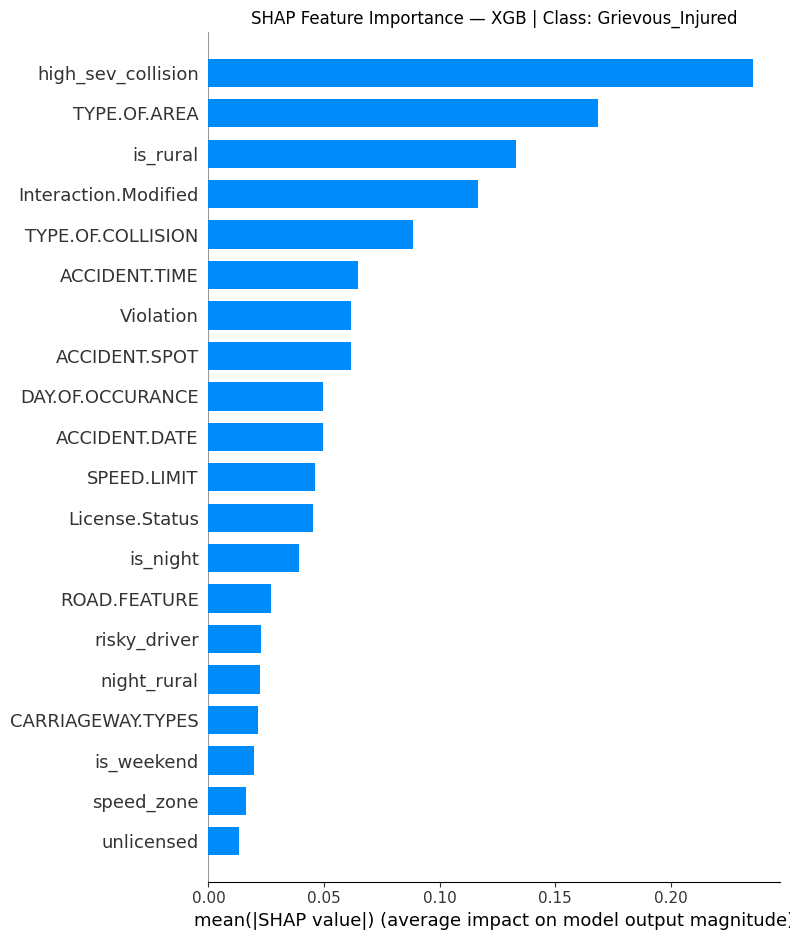

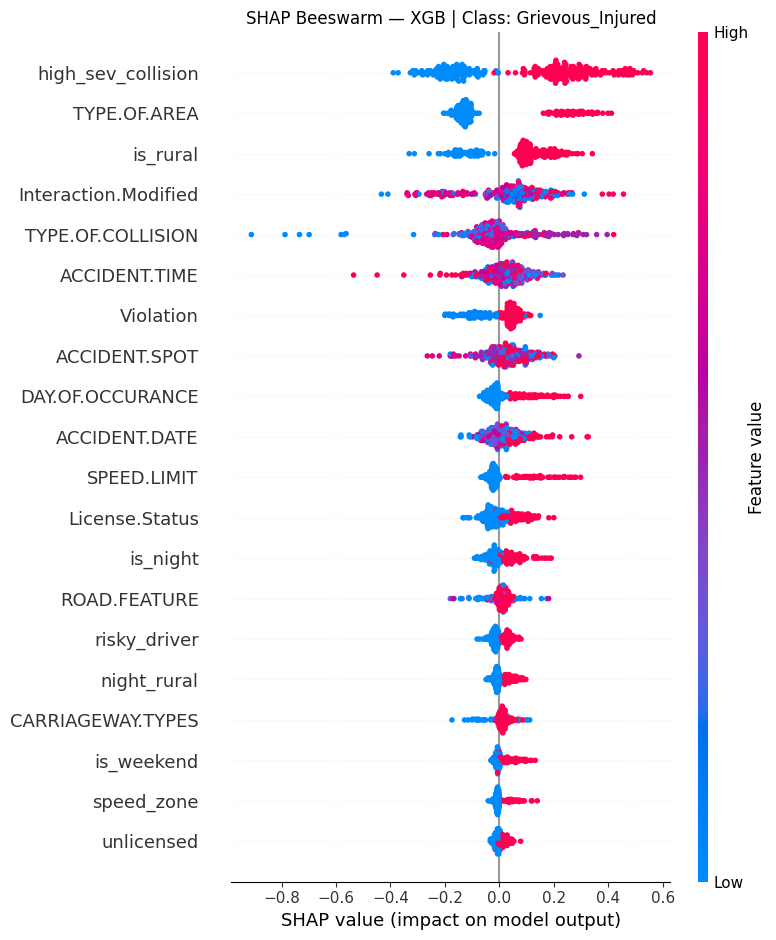

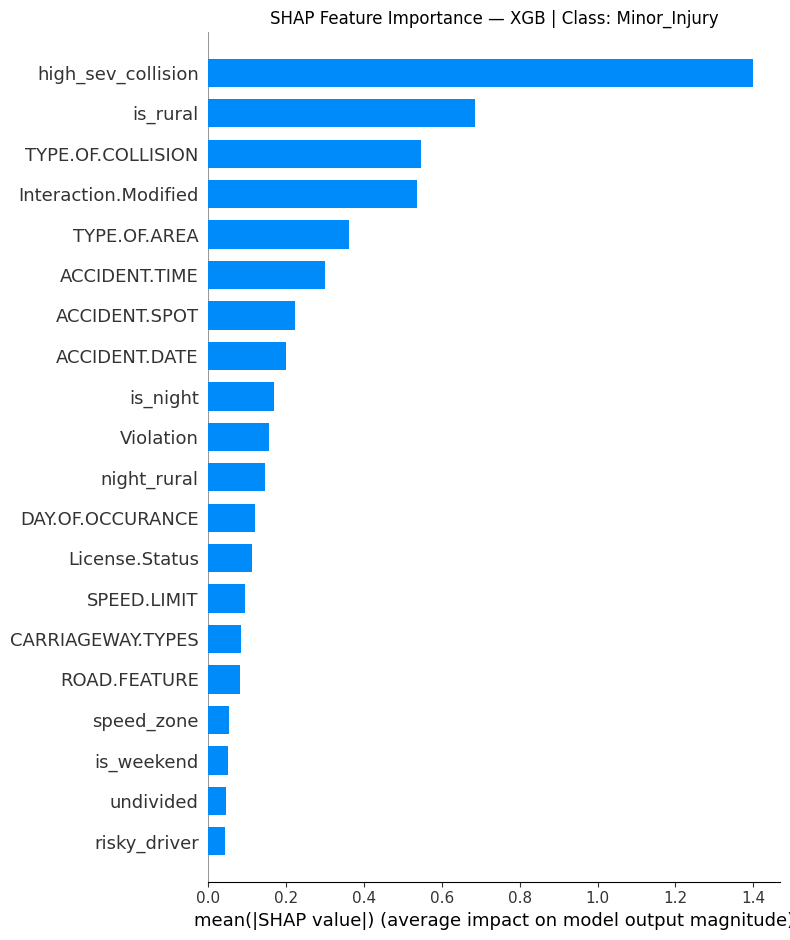

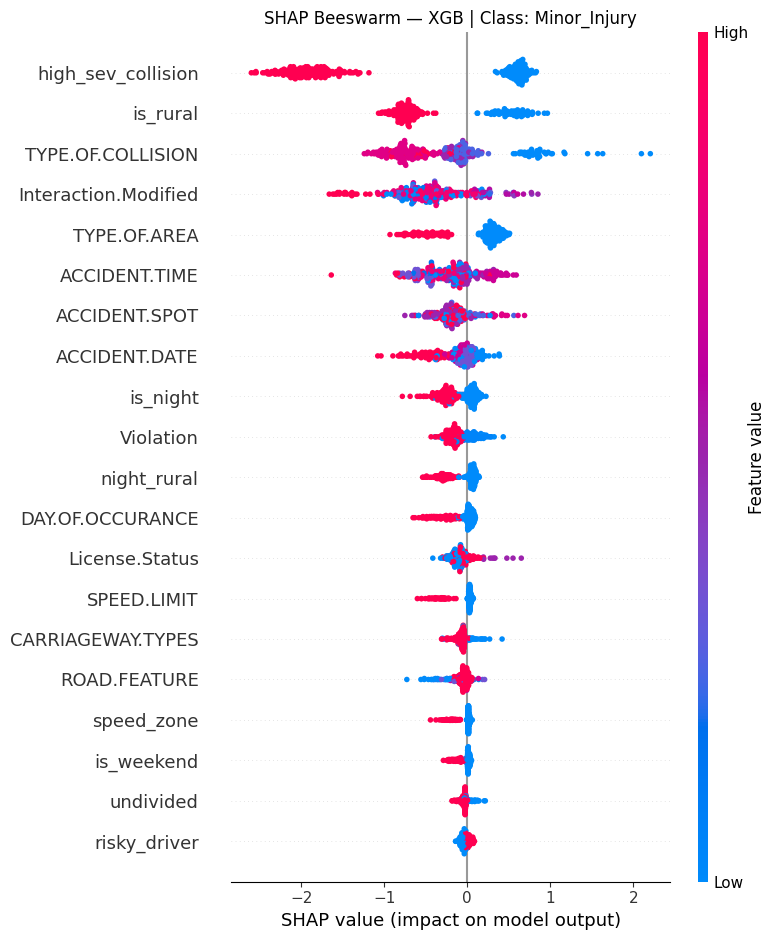


[XGB] SHAP per class + average:
             Feature  XGB_Fatal  XGB_Grievous_Injured  XGB_Minor_Injury  XGB_Average
  high_sev_collision   0.258066              0.235437          1.398993     0.630832
            is_rural   0.236801              0.133109          0.685619     0.351843
Interaction.Modified   0.192414              0.116488          0.536457     0.281786
   TYPE.OF.COLLISION   0.134324              0.088541          0.545755     0.256207
        TYPE.OF.AREA   0.081219              0.168485          0.361061     0.203588
       ACCIDENT.TIME   0.105843              0.064549          0.299132     0.156508
       ACCIDENT.SPOT   0.066470              0.061567          0.221495     0.116511
       ACCIDENT.DATE   0.063623              0.049438          0.198143     0.103735
           Violation   0.038521              0.061585          0.155547     0.085218
            is_night   0.034241              0.039264          0.169357     0.080954
      License.Status   0.055807 

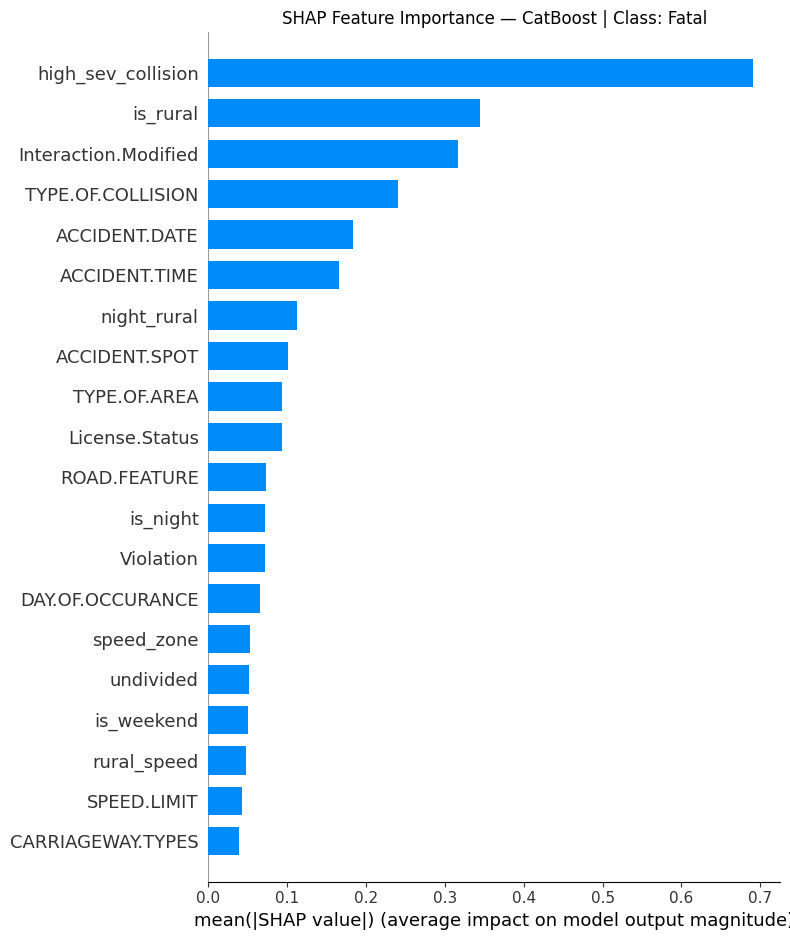

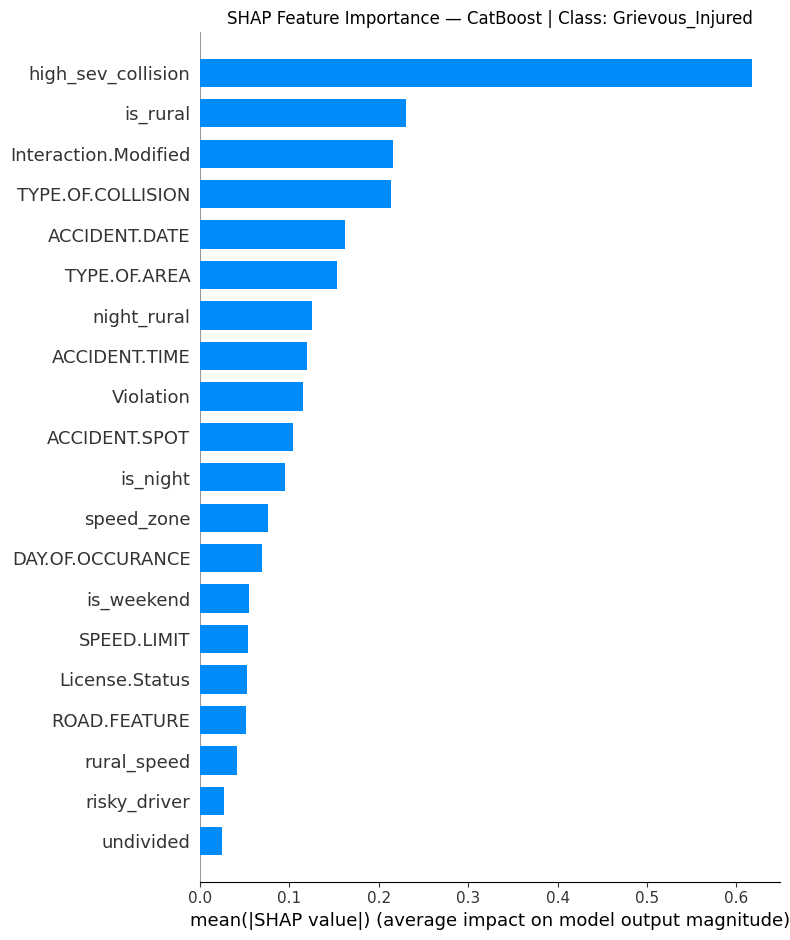

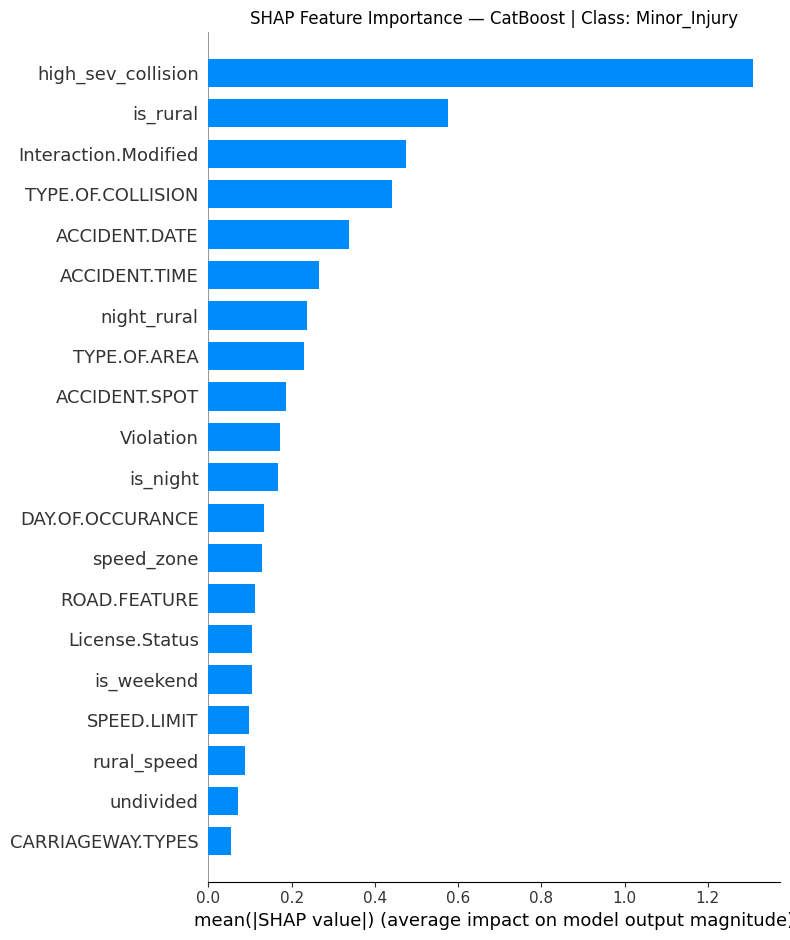


[CatBoost] SHAP per class + average:
             Feature  CAT_Fatal  CAT_Grievous_Injured  CAT_Minor_Injury  CAT_Average
  high_sev_collision   0.690431              0.617801          1.308232     0.872155
            is_rural   0.344410              0.230554          0.574964     0.383309
Interaction.Modified   0.316349              0.215629          0.474581     0.335520
   TYPE.OF.COLLISION   0.240231              0.213953          0.441565     0.298583
       ACCIDENT.DATE   0.183439              0.161927          0.337233     0.227533
       ACCIDENT.TIME   0.165318              0.119826          0.265969     0.183704
        TYPE.OF.AREA   0.093843              0.153137          0.228911     0.158630
         night_rural   0.111931              0.125135          0.236991     0.158019
       ACCIDENT.SPOT   0.100312              0.103536          0.187287     0.130378
           Violation   0.071839              0.114807          0.172152     0.119599
            is_night   0.07

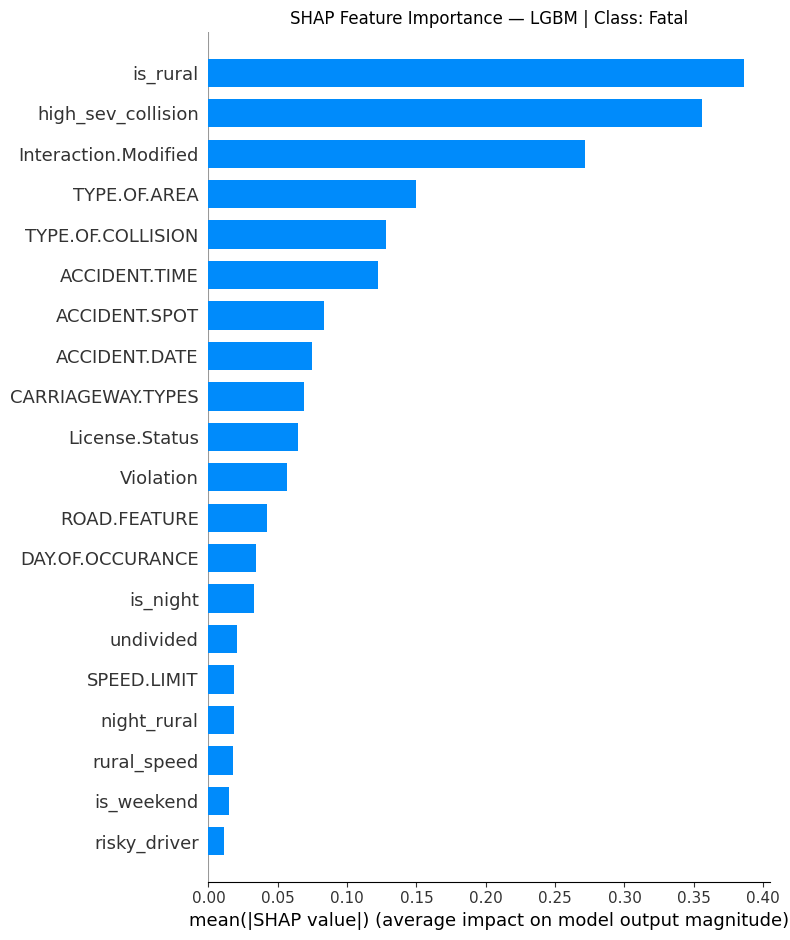

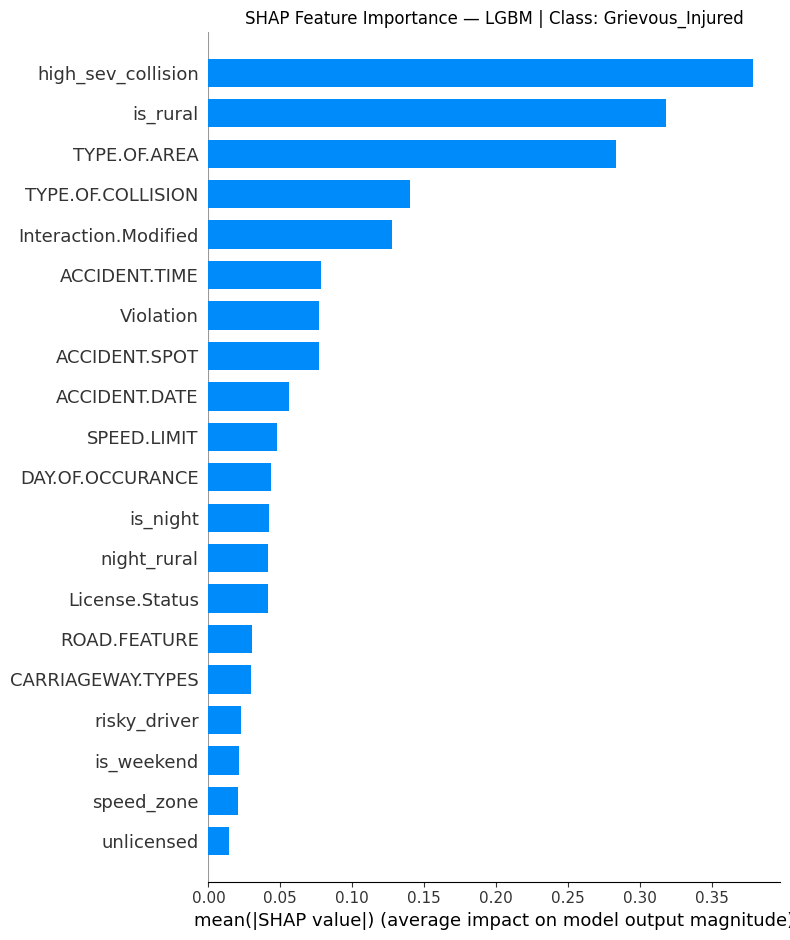

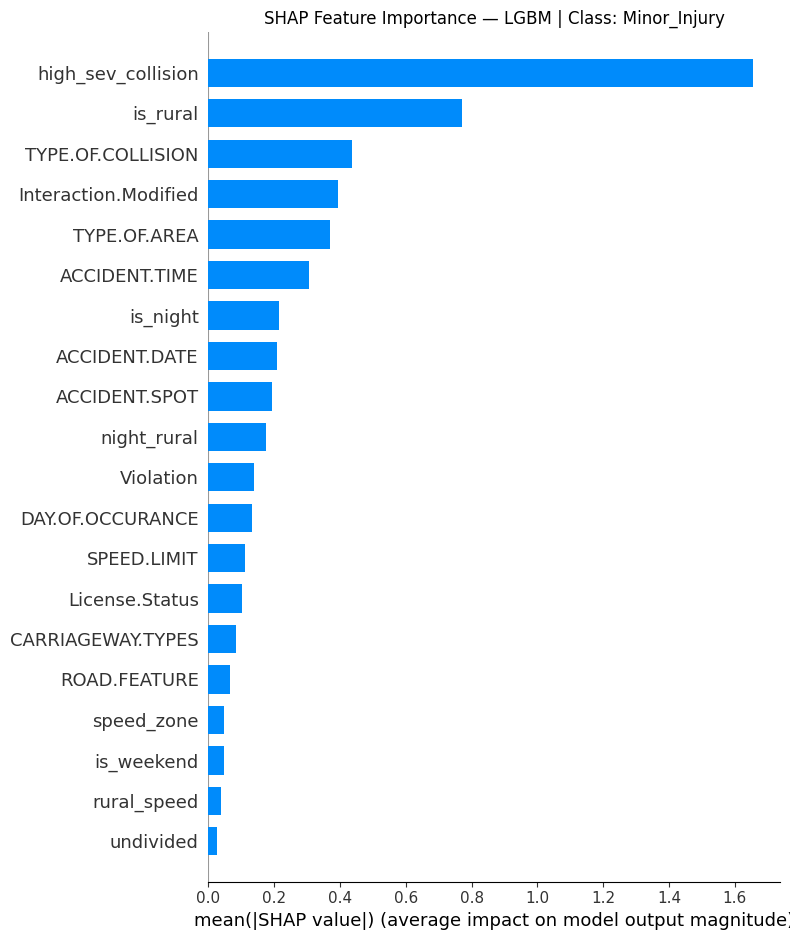


[LGBM] SHAP per class + average:
             Feature  LGBM_Fatal  LGBM_Grievous_Injured  LGBM_Minor_Injury  LGBM_Average
  high_sev_collision    0.355604               0.378634           1.654702      0.796313
            is_rural    0.385873               0.317997           0.769255      0.491042
        TYPE.OF.AREA    0.149920               0.283181           0.369323      0.267475
Interaction.Modified    0.271813               0.127478           0.394029      0.264440
   TYPE.OF.COLLISION    0.127821               0.140371           0.435134      0.234442
       ACCIDENT.TIME    0.122440               0.078417           0.305060      0.168639
       ACCIDENT.SPOT    0.083199               0.076628           0.191866      0.117231
       ACCIDENT.DATE    0.074369               0.055776           0.207198      0.112448
            is_night    0.032780               0.042175           0.214149      0.096368
           Violation    0.056871               0.077117           0.137546  

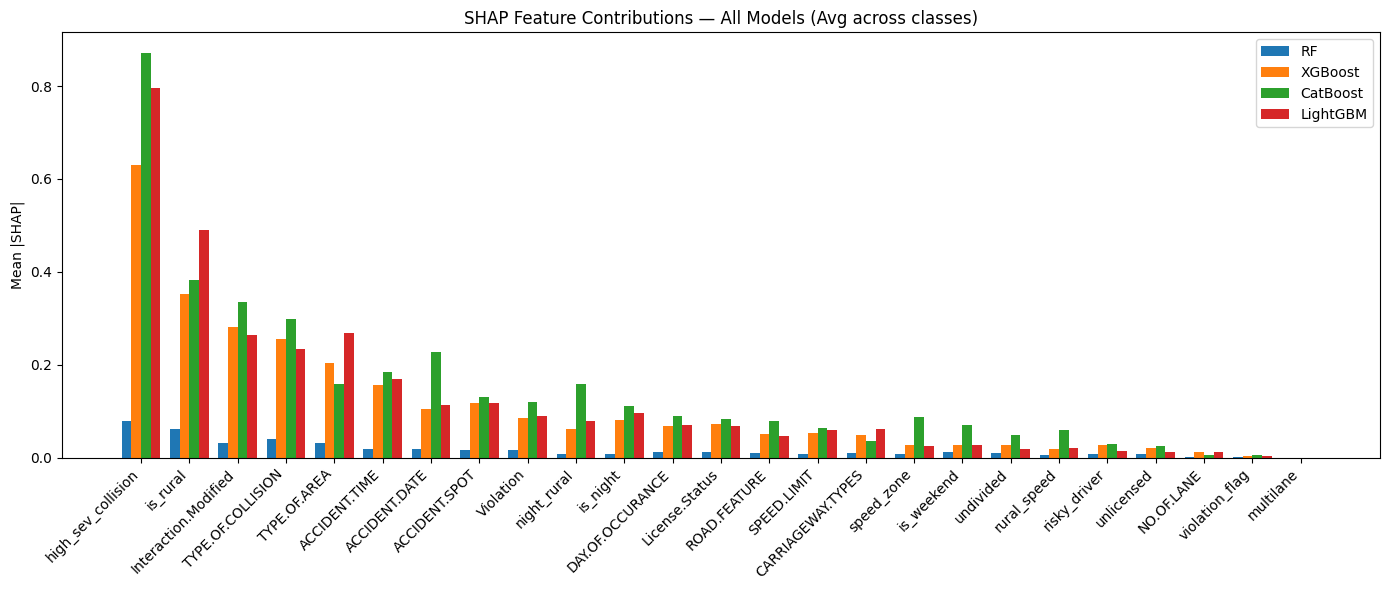

<Figure size 640x480 with 0 Axes>

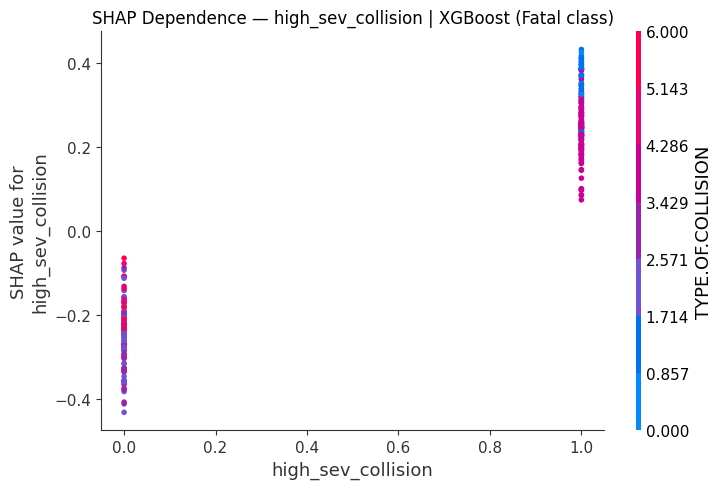

<Figure size 640x480 with 0 Axes>

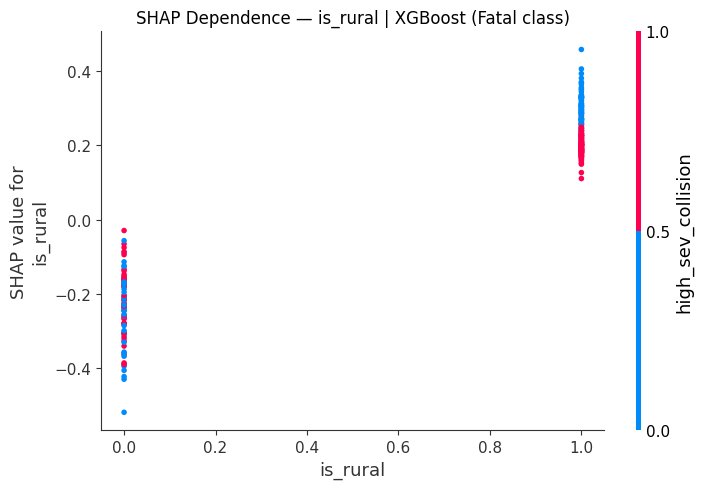

<Figure size 640x480 with 0 Axes>

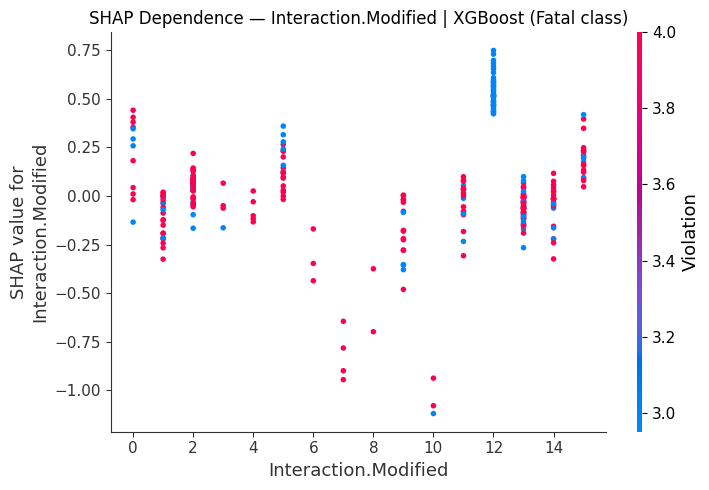

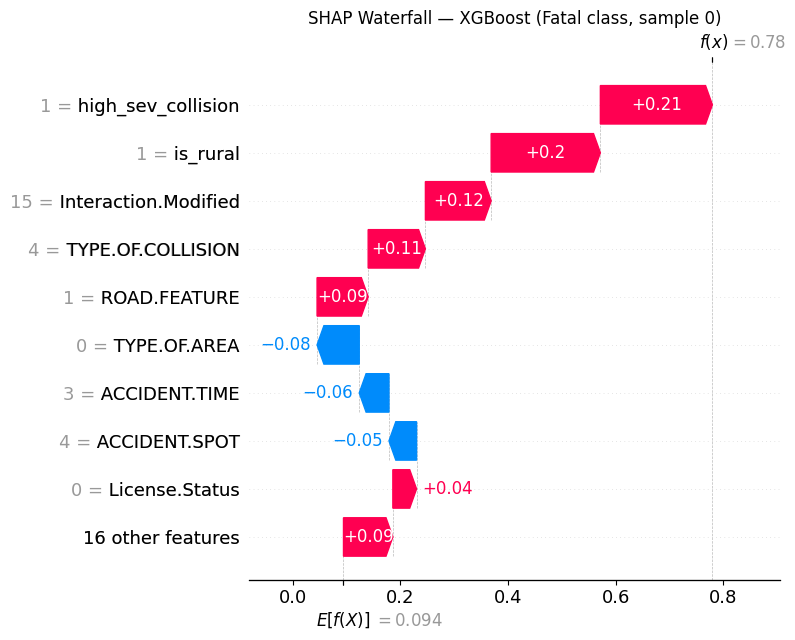

In [ ]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)
shap_sample = X_test_df.sample(n=min(300, len(X_test_df)), random_state=42)

def extract_shap_multiclass(raw_shap, class_idx=0):
    """
    Handles all TreeExplainer output shapes for multiclass:
      - list of arrays, one per class  → take class_idx
      - 3D ndarray (n, f, c)           → take [:, :, class_idx]
      - 2D ndarray (n, f)              → use directly
    Returns 2D array (n_samples, n_features).
    """
    if isinstance(raw_shap, list):
        return np.array(raw_shap[class_idx])
    arr = np.array(raw_shap)
    if arr.ndim == 3:
        return arr[:, :, class_idx]
    return arr

class_names = list(target_le.classes_)
class_labels = ['Fatal', 'Grievous_Injured', 'Minor_Injury']

# ── SHAP: Random Forest ──────────────────────────────────────
print("\n[SHAP] Random Forest ...")
rf_explainer = shap.TreeExplainer(rf_best)
rf_shap_raw = rf_explainer.shap_values(shap_sample)

# One summary plot per class
for i, label in enumerate(class_labels):
    sv = extract_shap_multiclass(rf_shap_raw, class_idx=i)
    plt.figure()
    shap.summary_plot(sv, shap_sample, feature_names=feature_names,
                      show=False, plot_type='bar')
    plt.title(f'SHAP Feature Importance — RF | Class: {label}')
    plt.tight_layout()
    plt.savefig(f'/content/shap_rf_bar_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Aggregate across all classes (mean over classes)
rf_all = np.array([np.abs(extract_shap_multiclass(rf_shap_raw, i)).mean(axis=0)
                   for i in range(n_classes)])
rf_mean_shap = pd.DataFrame({
    'Feature': feature_names,
    **{f'RF_{class_labels[i]}': rf_all[i] for i in range(n_classes)},
    'RF_Average': rf_all.mean(axis=0)
}).sort_values('RF_Average', ascending=False)
print("\n[RF] SHAP per class + average:")
print(rf_mean_shap.to_string(index=False))

# ── SHAP: XGBoost ────────────────────────────────────────────
print("\n[SHAP] XGBoost ...")
xgb_explainer = shap.TreeExplainer(xgb_best)
xgb_shap_raw = xgb_explainer.shap_values(shap_sample)

for i, label in enumerate(class_labels):
    sv = extract_shap_multiclass(xgb_shap_raw, class_idx=i)
    plt.figure()
    shap.summary_plot(sv, shap_sample, feature_names=feature_names,
                      show=False, plot_type='bar')
    plt.title(f'SHAP Feature Importance — XGB | Class: {label}')
    plt.tight_layout()
    plt.savefig(f'/content/shap_xgb_bar_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure()
    shap.summary_plot(sv, shap_sample, feature_names=feature_names, show=False)
    plt.title(f'SHAP Beeswarm — XGB | Class: {label}')
    plt.tight_layout()
    plt.savefig(f'/content/shap_xgb_beeswarm_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

xgb_all = np.array([np.abs(extract_shap_multiclass(xgb_shap_raw, i)).mean(axis=0)
                    for i in range(n_classes)])
xgb_mean_shap = pd.DataFrame({
    'Feature': feature_names,
    **{f'XGB_{class_labels[i]}': xgb_all[i] for i in range(n_classes)},
    'XGB_Average': xgb_all.mean(axis=0)
}).sort_values('XGB_Average', ascending=False)
print("\n[XGB] SHAP per class + average:")
print(xgb_mean_shap.to_string(index=False))

# ── SHAP: CatBoost ───────────────────────────────────────────
print("\n[SHAP] CatBoost ...")
cat_explainer = shap.TreeExplainer(cat_best)
cat_shap_raw = cat_explainer.shap_values(shap_sample)

for i, label in enumerate(class_labels):
    sv = extract_shap_multiclass(cat_shap_raw, class_idx=i)
    plt.figure()
    shap.summary_plot(sv, shap_sample, feature_names=feature_names,
                      show=False, plot_type='bar')
    plt.title(f'SHAP Feature Importance — CatBoost | Class: {label}')
    plt.tight_layout()
    plt.savefig(f'/content/shap_cat_bar_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

cat_all = np.array([np.abs(extract_shap_multiclass(cat_shap_raw, i)).mean(axis=0)
                    for i in range(n_classes)])
cat_mean_shap = pd.DataFrame({
    'Feature': feature_names,
    **{f'CAT_{class_labels[i]}': cat_all[i] for i in range(n_classes)},
    'CAT_Average': cat_all.mean(axis=0)
}).sort_values('CAT_Average', ascending=False)
print("\n[CatBoost] SHAP per class + average:")
print(cat_mean_shap.to_string(index=False))

# ── SHAP: LightGBM ───────────────────────────────────────────
print("\n[SHAP] LightGBM ...")
lgbm_explainer = shap.TreeExplainer(lgbm_best)
lgbm_shap_raw = lgbm_explainer.shap_values(shap_sample)

for i, label in enumerate(class_labels):
    sv = extract_shap_multiclass(lgbm_shap_raw, class_idx=i)
    plt.figure()
    shap.summary_plot(sv, shap_sample, feature_names=feature_names,
                      show=False, plot_type='bar')
    plt.title(f'SHAP Feature Importance — LGBM | Class: {label}')
    plt.tight_layout()
    plt.savefig(f'/content/shap_lgbm_bar_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

lgbm_all = np.array([np.abs(extract_shap_multiclass(lgbm_shap_raw, i)).mean(axis=0)
                     for i in range(n_classes)])
lgbm_mean_shap = pd.DataFrame({
    'Feature': feature_names,
    **{f'LGBM_{class_labels[i]}': lgbm_all[i] for i in range(n_classes)},
    'LGBM_Average': lgbm_all.mean(axis=0)
}).sort_values('LGBM_Average', ascending=False)
print("\n[LGBM] SHAP per class + average:")
print(lgbm_mean_shap.to_string(index=False))

# ── SHAP: Consolidated Cross-Model Table ──────────────────────
combined_shap = pd.DataFrame({'Feature': feature_names})
combined_shap['RF']       = rf_all.mean(axis=0)
combined_shap['XGBoost']  = xgb_all.mean(axis=0)
combined_shap['CatBoost'] = cat_all.mean(axis=0)
combined_shap['LightGBM'] = lgbm_all.mean(axis=0)
combined_shap['Average']  = combined_shap[['RF','XGBoost','CatBoost','LightGBM']].mean(axis=1)
combined_shap = combined_shap.sort_values('Average', ascending=False).reset_index(drop=True)

print("\n[SHAP] Consolidated Feature Importance Across All Models:")
print(combined_shap.to_string(index=False))

plt.figure(figsize=(14, 6))
x = np.arange(len(combined_shap))
width = 0.2
for i, col in enumerate(['RF', 'XGBoost', 'CatBoost', 'LightGBM']):
    plt.bar(x + i*width, combined_shap[col], width, label=col)
plt.xticks(x + width*1.5, combined_shap['Feature'], rotation=45, ha='right')
plt.ylabel('Mean |SHAP|')
plt.title('SHAP Feature Contributions — All Models (Avg across classes)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/or_shap_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SHAP: Dependence plots top 3 features (XGBoost, Fatal class) ──
top3 = combined_shap['Feature'].iloc[:3].tolist()
xgb_fatal_shap = extract_shap_multiclass(xgb_shap_raw, class_idx=0)
for feat in top3:
    plt.figure()
    shap.dependence_plot(feat, xgb_fatal_shap, shap_sample,
                         feature_names=feature_names, show=False)
    plt.title(f'SHAP Dependence — {feat} | XGBoost (Fatal class)')
    plt.tight_layout()
    plt.savefig(f'/content/shap_dep_{feat.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── SHAP: Waterfall single prediction (XGBoost, Fatal class) ──
exp_val = xgb_explainer.expected_value
if isinstance(exp_val, (list, np.ndarray)):
    exp_val = float(np.array(exp_val).flat[0])

xgb_exp = shap.Explanation(
    values=xgb_fatal_shap[0],
    base_values=exp_val,
    data=shap_sample.iloc[0].values,
    feature_names=feature_names)
plt.figure()
shap.waterfall_plot(xgb_exp, show=False)
plt.title('SHAP Waterfall — XGBoost (Fatal class, sample 0)')
plt.tight_layout()
plt.savefig('/content/shap_waterfall_xgb_fatal.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import joblib, os, shutil, glob
os.makedirs('/content/or_saved_models', exist_ok=True)
joblib.dump(lr,        '/content/or_saved_models/logistic_regression.pkl')
joblib.dump(dt_best,   '/content/or_saved_models/decision_tree.pkl')
joblib.dump(rf_best,   '/content/or_saved_models/random_forest.pkl')
joblib.dump(xgb_best,  '/content/or_saved_models/xgboost.pkl')
joblib.dump(cat_best,  '/content/or_saved_models/catboost.pkl')
joblib.dump(lgbm_best, '/content/or_saved_models/lightgbm.pkl')
joblib.dump(ensemble,  '/content/or_saved_models/ensemble.pkl')
joblib.dump(le_dict,   '/content/or_saved_models/label_encoders.pkl')
joblib.dump(target_le, '/content/or_saved_models/target_encoder.pkl')
shutil.make_archive('/content/or_saved_models', 'zip', '/content/or_saved_models')

'/content/or_saved_models.zip'

In [ ]:
# zip all plots
os.makedirs('/content/or_plots', exist_ok=True)
for f in glob.glob('/content/or_*.png') + glob.glob('/content/shap_*.png'):
    shutil.copy(f, '/content/or_plots/')
shutil.make_archive('/content/or_plots', 'zip', '/content/or_plots')
print("\n✅ All done!")
print("Download or_saved_models.zip and or_plots.zip from the sidebar.")


✅ All done!
Download or_saved_models.zip and or_plots.zip from the sidebar.


In [11]:
!git add CrashDetection2.ipynb
!git commit -m "Upload actual notebook content"
!git push origin main

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 1.42 MiB | 3.67 MiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push
remote:     
remote:     
remote:   